# 03 — PRIO Persistence Pipeline

**Fonte:** UCDP/PRIO Armed Conflict Dataset v25.1  
**Entrada:** `data/raw/ucdp/UcdpPrioConflict_v25_1.csv`  
**Saída:** `data/final/conflict_country_year_prio.csv`  
**Chave de junção:** `country` + `year` (mesma do dataset base)

---

## Posição no pipeline

```
notebooks/exploration/01_ucdp_country_year_eda.ipynb
notebooks/modeling/01_baseline_models.ipynb          — F1 = 0.8571
notebooks/modeling/02_temporal_features_models.ipynb — F1 = 0.8670
notebooks/modeling/03_prio_persistence_pipeline.ipynb  ← ESTE
notebooks/modeling/03_world_bank_features_models.ipynb
notebooks/modeling/04_world_bank_engineered_features_models.ipynb
notebooks/modeling/05_probability_calibration.ipynb
```

## O que este notebook adiciona

O UCDP Country-Year (base atual) captura **se há violência** num país num dado ano.  
O PRIO captura **como o conflito evolui ao longo do tempo** — duração, intensidade histórica, recorrência, trajetória de escalada.

As features de persistência estrutural são geradas por `src/features/build_prio_features.py`
e importadas aqui. O notebook se concentra em análise exploratória e avaliação de modelo.


## 1. Imports e configuração


In [1]:
import sys
from pathlib import Path

import matplotlib
import matplotlib.pyplot as plt
import pandas as pd

matplotlib.rcParams["figure.dpi"] = 120

PROJECT_ROOT = Path.cwd().parents[1]
sys.path.insert(0, str(PROJECT_ROOT / "src"))

from data.prepare_prio_dataset import (
    load_prio, load_mapping, load_base_countries,
    prepare_prio, save_intermediate,
)
from features.build_prio_features import (
    load_intermediate, load_base,
    build_prio_features, save_dataset,
    PRIO_FEATURE_COLS, OUTPUT_PATH,
)

## 2. Gerar dataset com features PRIO

A função `build_prio_dataset()` executa o pipeline completo:
carrega o PRIO, expande conflitos multi-país, mapeia nomes de país,
calcula features de ciclo de vida e intensidade, colapsa para country-year
e faz o JOIN com o dataset base.


In [2]:
df_prepared = prepare_prio(load_prio(), load_mapping(), load_base_countries())
save_intermediate(df_prepared)

df_enriched, feature_cols = build_prio_features(load_intermediate(), load_base())

print(f"Shape final        : {df_enriched.shape}")
print(f"Anos cobertos      : {df_enriched['year'].min()} – {df_enriched['year'].max()}")
print(f"Países únicos      : {df_enriched['country'].nunique()}")
print(f"Features PRIO      : {len(feature_cols)}")
print()
df_enriched[["country", "year"] + feature_cols].head()

[AVISO] 119 locais sem mapeamento:
 gwno_loc_clean                                                      location
            770                                         Afghanistan, Pakistan
            700                                         Afghanistan, Pakistan
            700                            Afghanistan, Russia (Soviet Union)
            365                            Afghanistan, Russia (Soviet Union)
              2         Afghanistan, United Kingdom, United States of America
            200         Afghanistan, United Kingdom, United States of America
            700         Afghanistan, United Kingdom, United States of America
            200                                       Albania, United Kingdom
            339                                       Albania, United Kingdom
            615                                              Algeria, Morocco
            600                                              Algeria, Morocco
            160              

,country,year,prio_n_conflicts_active,prio_max_intensity,prio_max_intensity_trend,prio_max_intensity_ma3,prio_mean_intensity_ma3,prio_mean_conflict_age,prio_any_war_level,prio_any_recurring,prio_any_cumulative_war,prio_sum_episode_duration,prio_max_years_same_intens,prio_total_episodes,prio_has_interstate,prio_has_internationalized
0,United States Of America,1989,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,United States Of America,1990,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,United States Of America,1991,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,United States Of America,1992,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,United States Of America,1993,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## 3. Validação — consistência com o target

Países com guerra ativa (`prio_any_war_level = 1`) devem apresentar
taxa de conflito no ano seguinte sistematicamente maior.


In [3]:
TARGET = "target_conflict_next_year"

checks = [
    ("prio_any_war_level",      "Com guerra ativa (PRIO)",    "Sem guerra (PRIO)"),
    ("prio_any_recurring",      "Conflito recorrente",         "Não recorrente"),
    ("prio_any_cumulative_war", "Já atingiu guerra algum dia", "Nunca atingiu guerra"),
    ("prio_has_interstate",     "Conflito interstate ativo",   "Sem interstate"),
]

print("=== Taxa de target por flag PRIO ===")
for col, label_1, label_0 in checks:
    taxa = (
        df_enriched.groupby(col)[TARGET]
        .mean()
        .rename({0: label_0, 1: label_1})
        .round(4)
    )
    print(f"{col}:")
    print(taxa.to_string())


=== Taxa de target por flag PRIO ===
prio_any_war_level:
prio_any_war_level
Sem guerra (PRIO)          0.2670
Com guerra ativa (PRIO)    0.9665
prio_any_recurring:
prio_any_recurring
Não recorrente         0.2194
Conflito recorrente    0.9538
prio_any_cumulative_war:
prio_any_cumulative_war
Nunca atingiu guerra           0.1982
Já atingiu guerra algum dia    0.9493
prio_has_interstate:
prio_has_interstate
Sem interstate    0.2949


## 4. Comparação rápida de F1

Treino rápido para medir o ganho das features PRIO sobre o baseline.
Usa o mesmo split temporal e as mesmas features base do notebook anterior.


In [4]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, f1_score

TRAIN_END_YEAR = 2016

FEATURE_COLUMNS_BASE = [
    "year",
    "state_based_conflict_exists",
    "state_based_dyad_count",
    "state_based_deaths_best",
    "intrastate_conflict_exists",
    "intrastate_deaths_best",
    "interstate_conflict_exists",
    "interstate_deaths_best",
    "non_state_conflict_exists",
    "non_state_dyad_count",
    "non_state_deaths_best",
    "one_sided_violence_exists",
    "one_sided_dyad_count",
    "one_sided_deaths_best",
    "cumulative_organized_violence_deaths_best",
    "organized_violence_exists",
]
FEATURE_COLUMNS_PRIO = FEATURE_COLUMNS_BASE + feature_cols

train_mask = df_enriched["year"] <= TRAIN_END_YEAR
test_mask  = df_enriched["year"] >  TRAIN_END_YEAR

y_train = df_enriched.loc[train_mask, TARGET]
y_test  = df_enriched.loc[test_mask,  TARGET]

rf_params = dict(
    n_estimators=300, max_depth=6, min_samples_leaf=5,
    class_weight="balanced", random_state=42, n_jobs=-1,
)

# Modelo BASE (referência — deve reproduzir F1 ≈ 0.8571)
rf_base = RandomForestClassifier(**rf_params)
rf_base.fit(df_enriched.loc[train_mask, FEATURE_COLUMNS_BASE], y_train)
f1_base = f1_score(
    y_test,
    rf_base.predict(df_enriched.loc[test_mask, FEATURE_COLUMNS_BASE]),
    zero_division=0,
)

# Modelo BASE + PRIO
rf_prio = RandomForestClassifier(**rf_params)
rf_prio.fit(df_enriched.loc[train_mask, FEATURE_COLUMNS_PRIO], y_train)
y_pred_prio = rf_prio.predict(df_enriched.loc[test_mask, FEATURE_COLUMNS_PRIO])
f1_prio = f1_score(y_test, y_pred_prio, zero_division=0)

print("=" * 45)
print(f"  F1 Base (referência) : {f1_base:.4f}")
print(f"  F1 Base + PRIO       : {f1_prio:.4f}")
print(f"  Ganho                : {f1_prio - f1_base:+.4f}")
print("=" * 45)
print()
print("Relatório detalhado (Base + PRIO):")
print(classification_report(
    y_test, y_pred_prio,
    target_names=["Sem conflito", "Com conflito"],
    zero_division=0,
))


  F1 Base (referência) : 0.8571
  F1 Base + PRIO       : 0.8597
  Ganho                : +0.0026

Relatório detalhado (Base + PRIO):
              precision    recall  f1-score   support

Sem conflito       0.93      0.93      0.93       931
Com conflito       0.86      0.86      0.86       441

    accuracy                           0.91      1372
   macro avg       0.90      0.90      0.90      1372
weighted avg       0.91      0.91      0.91      1372



## 5. Importância das features


Top 15 features por importância:
organized_violence_exists                    0.1997
cumulative_organized_violence_deaths_best    0.1809
state_based_deaths_best                      0.0761
one_sided_dyad_count                         0.0748
intrastate_conflict_exists                   0.0638
state_based_dyad_count                       0.0603
intrastate_deaths_best                       0.0590
one_sided_violence_exists                    0.0561
state_based_conflict_exists                  0.0552
one_sided_deaths_best                        0.0512
prio_n_conflicts_active                      0.0178
non_state_deaths_best                        0.0163
non_state_conflict_exists                    0.0153
non_state_dyad_count                         0.0143
prio_sum_episode_duration                    0.0132

Features PRIO no top 15:
  ★ prio_n_conflicts_active             0.0178
  ★ prio_sum_episode_duration           0.0132


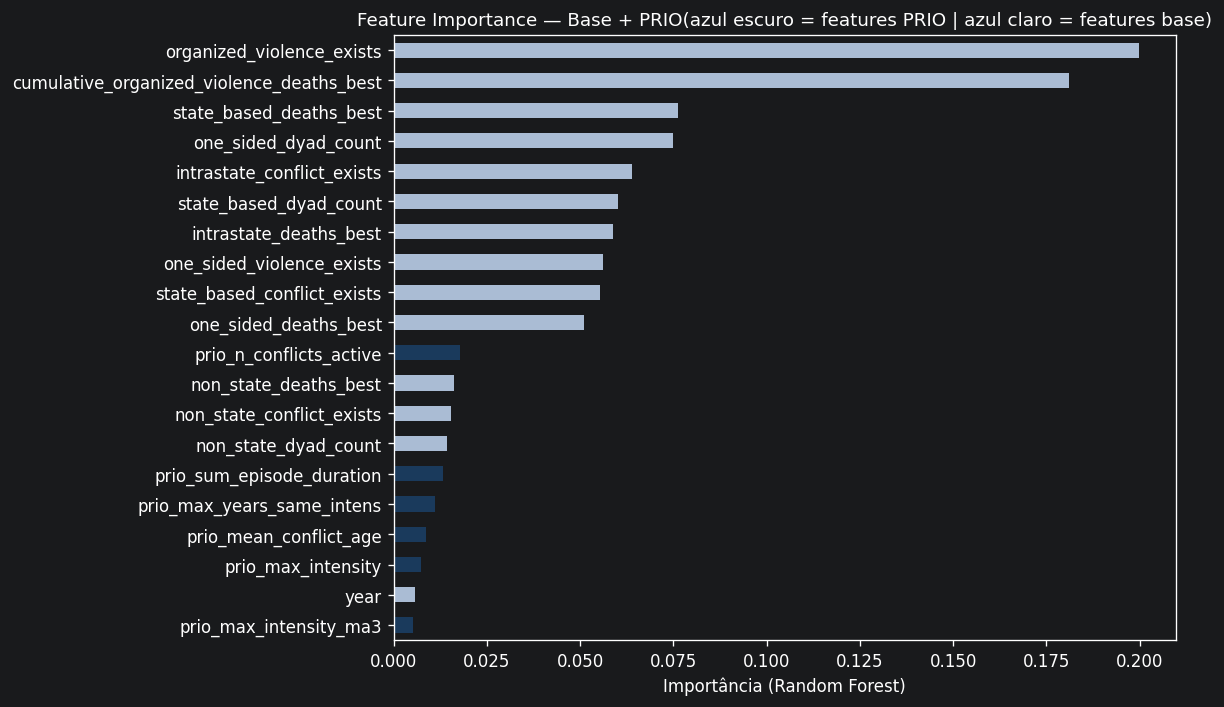

Gráfico salvo em: C:\Users\Leonardo\Desktop\Codigo\Git Enzo\international-conflict-risk-ml\outputs\charts\prio_feature_importance.png


In [5]:
importances = (
    pd.Series(rf_prio.feature_importances_, index=FEATURE_COLUMNS_PRIO)
    .sort_values(ascending=False)
)

print("Top 15 features por importância:")
print(importances.head(15).round(4).to_string())
print()
print("Features PRIO no top 15:")
for f in importances.head(15).index:
    if f in feature_cols:
        print(f"  ★ {f:<35} {importances[f]:.4f}")

fig, ax = plt.subplots(figsize=(10, 6))
cores = [
    "#1A3A5C" if f in feature_cols else "#AABCD4"
    for f in importances.head(20).sort_values().index
]
importances.head(20).sort_values().plot(kind="barh", ax=ax, color=cores)
ax.set_title(
    "Feature Importance — Base + PRIO"
    "(azul escuro = features PRIO | azul claro = features base)",
    fontsize=11,
)
ax.set_xlabel("Importância (Random Forest)")
plt.tight_layout()

chart_path = PROJECT_ROOT / "outputs" / "charts" / "prio_feature_importance.png"
chart_path.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(chart_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Gráfico salvo em: {chart_path}")


## 6. Salvar dataset enriquecido

Delega para `save_dataset()` de `src/features/build_prio_features.py`,
mantendo o mesmo padrão de todos os outros pipelines do projeto.


In [6]:
save_dataset(df_enriched)

print(f"Arquivo salvo : {OUTPUT_PATH}")
print(f"Shape final   : {df_enriched.shape}")
print()
print("Próximo passo:")
print("  notebooks/modeling/04_world_bank_engineered_features_models.ipynb")
print("  → Substituir BASE_PATH por OUTPUT_PATH deste notebook")
print("  → Adicionar PRIO_FEATURE_COLS à lista de features")


Arquivo salvo : C:\Users\Leonardo\Desktop\Codigo\Git Enzo\international-conflict-risk-ml\data\final\conflict_country_year_prio.csv
Shape final   : (6737, 36)

Próximo passo:
  notebooks/modeling/04_world_bank_engineered_features_models.ipynb
  → Substituir BASE_PATH por OUTPUT_PATH deste notebook
  → Adicionar PRIO_FEATURE_COLS à lista de features
